<a href="https://colab.research.google.com/github/SandraVargasAI/Mineria-de-Datos-/blob/main/Ejercicio_Integrador_Clase_3_Sandra_Vargas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Ejercicio Integrador**

**Objetivo:** Aplicar todo lo aprendido en esta clase mediante un ejercicio práctico que integre análisis exploratorio, PCA y Clustering y fomente la discusión con herramientas de IA en el foro de la clase.

#**4.1. Ejercicio Integrador**

Supongamos que estamos analizando un dataset de clientes de un banco que busca segmentar su base de clientes según sus ingresos y años de experiencia.

**Dataset para el ejercicio**

| Cliente | Edad | Ingresos | Años de Experiencia | Estado de Cuenta |
|---|---|---|---|---|
| 1 | 25 | 50000 | 2 | Pagado |
| 2 | 40 | 60000 | 10 | Moroso |
| 3 | 35 | 70000 | 7 | Pagado |
| 4 | 50 | 80000 | 15 | Moroso |
| 5 | 30 | 45000 | 3 | Pagado |
| 6 | 45 | 85000 | 20 | Moroso |
| 7 | 38 | 72000 | 12 | Pagado |
| 8 | 29 | 48000 | 4 | Pagado |

**Tareas a realizar**
1. Análisis Exploratorio de Datos (EDA)
* Generar histogramas de Edad e Ingresos.
* Calcular la correlación entre Edad, Ingresos y Experiencia.
* Visualizar relaciones con diagramas de dispersión.
2. Aplicación de PCA para Reducción de Dimensionalidad
* Normalizar los datos antes de aplicar PCA.
* Calcular cuántas componentes principales explican el 90% de la varianza.
* Visualizar los datos en 2D usando las dos primeras componentes principales.
3. Segmentación de Clientes con Clustering
* Aplicar K-Means Clustering con 3 clusters sobre los datos originales y luego sobre los datos transformados por PCA.
* Comparar los resultados y analizar si el agrupamiento cambia después de la reducción de dimensionalidad.
* Visualizar los clusters con gráficos de dispersión en 2D.
4. Interacción con una Herramienta de IA (LLM)
* Hacer una consulta a ChatGPT, Gemini u otra herramienta LLM para obtener insights sobre los clusters.
* Ejemplo de consulta: "Tengo datos de clientes con variables de edad, ingresos y experiencia. ¿Qué técnicas avanzadas puedo usar para
mejorar la segmentación?"
* Comparar la respuesta con lo aprendido en la clase y reflexionar sobre su utilidad.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Crear DataFrame
df = pd.DataFrame({
    'Cliente': [1, 2, 3, 4, 5, 6, 7, 8],
    'Edad': [25, 40, 35, 50, 30, 45, 38, 29],
    'Ingresos': [50000, 60000, 70000, 80000, 45000, 85000, 72000, 48000],
    'Años de Experiencia': [2, 10, 7, 15, 3, 20, 12, 4],
    'Estado de Cuenta': ['Pagado', 'Moroso', 'Pagado', 'Moroso', 'Pagado', 'Moroso', 'Pagado', 'Pagado']
})
display(df)

numericas = df.select_dtypes(include=['number']).columns.tolist()
categoricas = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f'\nVariables NUMÉRICAS:\n{numericas}\n\nVariables CATEGÓRICAS:\n{categoricas}\n')

,Cliente,Edad,Ingresos,Años de Experiencia,Estado de Cuenta
0,1,25,50000,2,Pagado
1,2,40,60000,10,Moroso
2,3,35,70000,7,Pagado
3,4,50,80000,15,Moroso
4,5,30,45000,3,Pagado
5,6,45,85000,20,Moroso
6,7,38,72000,12,Pagado
7,8,29,48000,4,Pagado



Variables NUMÉRICAS:
['Cliente', 'Edad', 'Ingresos', 'Años de Experiencia']

Variables CATEGÓRICAS:
['Estado de Cuenta']



In [2]:
# Codificar variable categórica 'Estado de Cuenta'
df['Estado_Cuenta_Cod'] = df['Estado de Cuenta'].map({'Pagado': 0, 'Moroso': 1})
display(df)

,Cliente,Edad,Ingresos,Años de Experiencia,Estado de Cuenta,Estado_Cuenta_Cod
0,1,25,50000,2,Pagado,0
1,2,40,60000,10,Moroso,1
2,3,35,70000,7,Pagado,0
3,4,50,80000,15,Moroso,1
4,5,30,45000,3,Pagado,0
5,6,45,85000,20,Moroso,1
6,7,38,72000,12,Pagado,0
7,8,29,48000,4,Pagado,0


# **1. Análisis Exploratorio de Datos (EDA)**

In [3]:
# 1) Análisis Exploratorio
# Verificamos si hay valores faltantes, duplicados o valores atípicos.
print(df.isnull().sum())
print(df.duplicated().sum())
print(df[df["Edad"] < 0])

# Obtenemos el Resumen Estadístico
df.describe()


Cliente                0
Edad                   0
Ingresos               0
Años de Experiencia    0
Estado de Cuenta       0
Estado_Cuenta_Cod      0
dtype: int64
0
Empty DataFrame
Columns: [Cliente, Edad, Ingresos, Años de Experiencia, Estado de Cuenta, Estado_Cuenta_Cod]
Index: []


,Cliente,Edad,Ingresos,Años de Experiencia,Estado_Cuenta_Cod
count,8.00000,8.000000,8.000000,8.00000,8.000000
mean,4.50000,36.500000,63750.000000,9.12500,0.375000
std,2.44949,8.468429,15238.578861,6.33443,0.517549
min,1.00000,25.000000,45000.000000,2.00000,0.000000
25%,2.75000,29.750000,49500.000000,3.75000,0.000000
50%,4.50000,36.500000,65000.000000,8.50000,0.000000
75%,6.25000,41.250000,74000.000000,12.75000,1.000000
max,8.00000,50.000000,85000.000000,20.00000,1.000000


El dataset contiene información de oocho registros y no se observan faltantes ni duplicados.
Respecto a la edad, el promedio es de 36,5 años, el valor mínimo corresponde a 25 años y el valor máximo es de 50 años. Considerando el desvío estandar (8,47) se puede decir que hay una dispersión moderada.
Siguiendo con el análisis, el promedio de ingresos es de $$63.750, el valor minimo de salario es de $45.000.


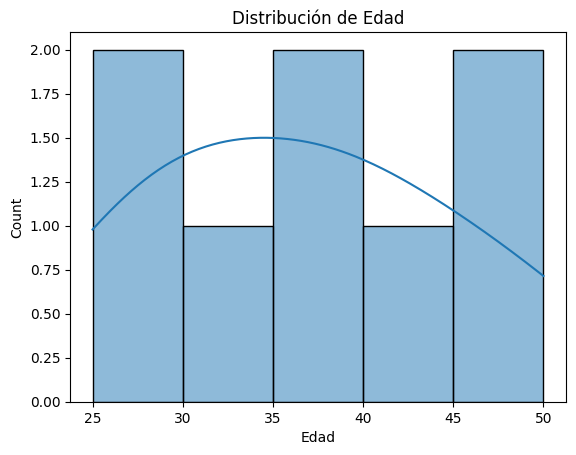

In [4]:
# Histograma de Edad e Ingresos
sns.histplot(df["Edad"], bins=5, kde=True)
plt.title("Distribución de Edad")
plt.show()

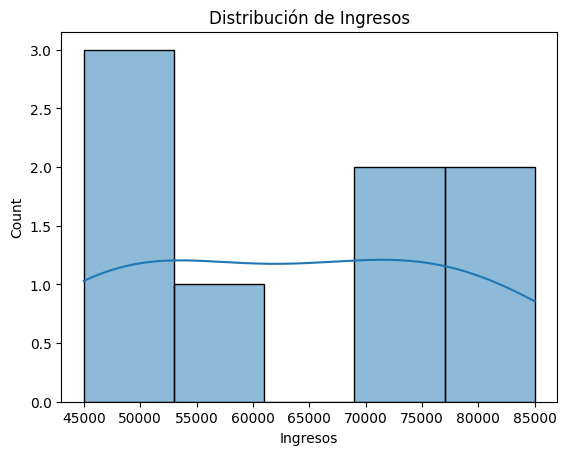

In [5]:
# Distribuciónd de Ingresos
sns.histplot(df["Ingresos"], bins=5, kde=True)
plt.title("Distribución de Ingresos")
plt.show()

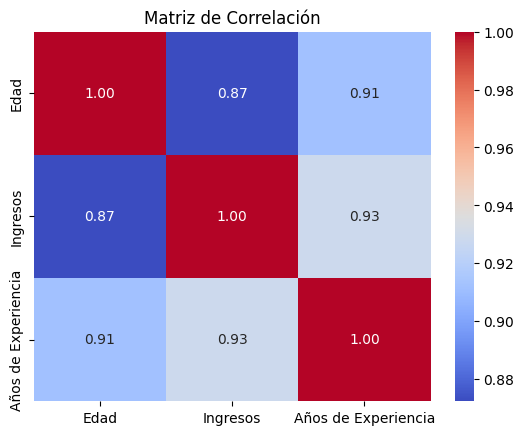

In [6]:
# Matriz de correlación entre Edad, Ingresoso y Experiencia
sns.heatmap(df[['Edad', 'Ingresos', 'Años de Experiencia']].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

La distribución muestra que la mayor concentración de los clientes, está entre la edad de 30 y 45 aproximadamente.
Respecto a la distribución de los ingresos, se observan dos grupos diferenciados. Hay ingresos bajos, con salarios entre $$45.000 y $53.000. el otro grupo corresponde a los ingresos más altos, con salarios entre $69.000 y $85.000.
La correlación entre las variables es positiva fuerte.

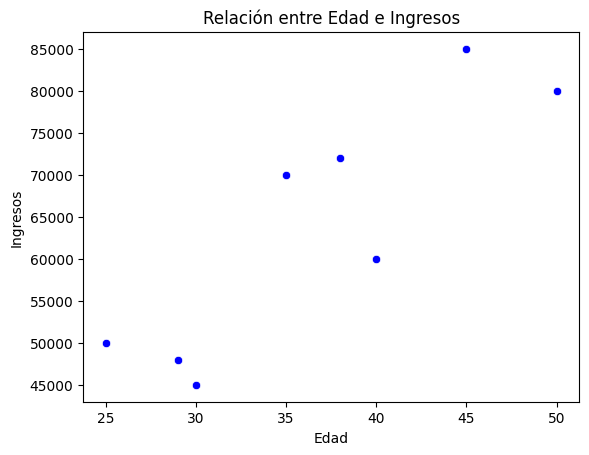

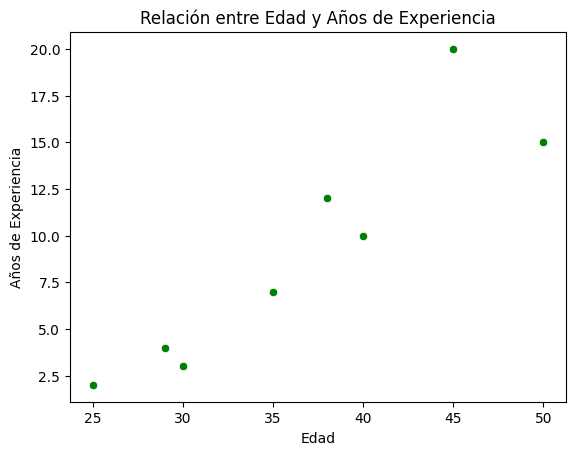

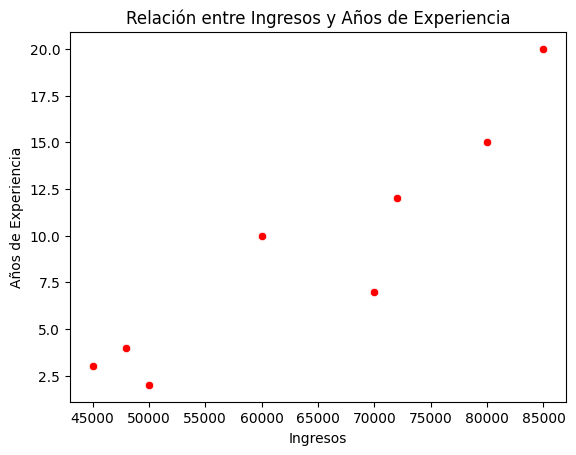

In [7]:
# Diagramas de dispersión para visualizar relaciones
sns.scatterplot(x='Edad', y='Ingresos', data=df, color ="blue")
plt.title('Relación entre Edad e Ingresos')
plt.show()

sns.scatterplot(x='Edad', y='Años de Experiencia', data=df, color ="green")
plt.title('Relación entre Edad y Años de Experiencia')
plt.show()

sns.scatterplot(x='Ingresos', y='Años de Experiencia', data=df, color ="red")
plt.title('Relación entre Ingresos y Años de Experiencia')
plt.show()

Considerando los tres gráficos, se evidencia que:

* La relación entre Edad e Ingresos, es fuerte, a mayor edad se obtienen mayores ingresos.

* La relación entre Edad y Años de Experiencia, es muy fuerte, se puede observar que es casi lineal, en éste caso cuanto más edad, más experiencia se adquiere.

* La relación entre Ingresos y Años de Experiencia, muestra una relación fuerte, indicando que cuanto más años de experiencia tenemos, tambien hay mayores ingresos.

# **2. Aplicación de PCA para Reducción de Dimensionalidad**

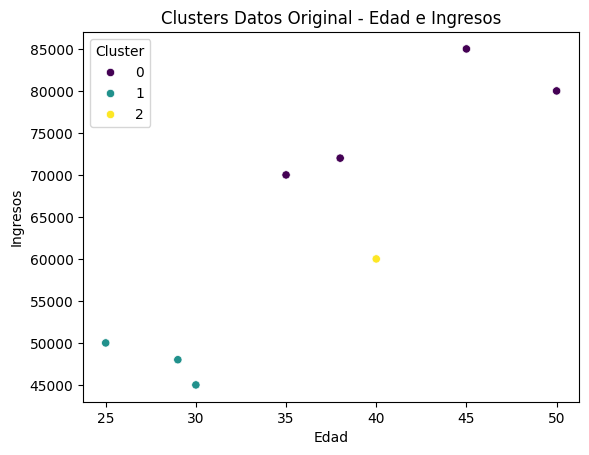

Varianza por  cada componente:
[0.9362353  0.04299134]
Varianza acumulada:
[0.9362353  0.97922665]

Cantidad de componentes para explicar el 90% de la varianza:  1

=== VARIANZA EXPLICADA ===
PC1: 93.62%
PC2: 4.30%
Total: 97.92%


In [11]:
# Cluster de datos originales
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(df[["Edad", "Ingresos"]])

# Visualizar clusters con datos originales
sns.scatterplot(x=df["Edad"], y=df["Ingresos"], hue=df["Cluster"], palette="viridis")
plt.title("Clusters Datos Original - Edad e Ingresos")
plt.show()

# Primero realizamos la Normalización de los datos
# media = 0 y D.E. = 1
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[["Edad", "Ingresos", "Años de Experiencia"]])

# 2) Aplicar PCA para reducir a 2 componente
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

df_pca = pd.DataFrame(df_pca, columns=["PC1", "PC2"])

# Calculamos cuantas componentes principales explican el 90% de la varianza
print('Varianza por  cada componente:')
print(pca.explained_variance_ratio_)

# Calculamos varianza acumulada
print('Varianza acumulada:')
print(pca.explained_variance_ratio_.cumsum())

# Calcular cantidad de componentes (90%)
print('\nCantidad de componentes para explicar el 90% de la varianza: ', sum(pca.explained_variance_ratio_ >= 0.90))

print("\n=== VARIANZA EXPLICADA ===")
print(f"PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"Total: {sum(pca.explained_variance_ratio_)*100:.2f}%")

### Interpretación de los Componentes Principales (Loadings)

Los loadings de PCA nos indican la correlación entre las variables originales y los componentes principales. Un valor alto (positivo o negativo) en un loading significa que esa variable tiene una fuerte influencia en ese componente. El signo indica la dirección de la relación.


In [12]:
pca_components = pd.DataFrame(pca.components_, columns=["Edad", "Ingresos", "Años de Experiencia"], index=["PC1", "PC2"])
display(pca_components)

print("\nAnálisis de los Componentes Principales (Loadings):")
print("PC1: Esta componente está fuertemente correlacionada con todas las variables (Edad, Ingresos, Años de Experiencia), y todas con el mismo signo.")
print("Esto sugiere que PC1 representa una dimensión general de 'estatus socioeconómico' o 'experiencia de vida',")
print("donde un valor alto en PC1 indica mayor edad, mayores ingresos y más años de experiencia.")
print("Dada la alta correlación entre estas variables en tu dataset, PC1 captura la mayor parte de la varianza conjunta.")
print("PC2: Esta componente tiene una contribución menor y es más difícil de interpretar directamente sin un contexto más amplio.")
print("Podría capturar variaciones residuales no explicadas por PC1 o diferencias sutiles entre las variables.")
print("Por ejemplo, tiene un peso negativo en Edad y positivo en Ingresos, lo que podría indicar alguna variación")
print("donde Ingresos no escala perfectamente con Edad, pero su influencia es mucho menor que PC1.")

,Edad,Ingresos,Años de Experiencia
PC1,0.572206,0.575731,0.584050
PC2,0.759616,-0.640511,-0.112824



Análisis de los Componentes Principales (Loadings):
PC1: Esta componente está fuertemente correlacionada con todas las variables (Edad, Ingresos, Años de Experiencia), y todas con el mismo signo.
Esto sugiere que PC1 representa una dimensión general de 'estatus socioeconómico' o 'experiencia de vida',
donde un valor alto en PC1 indica mayor edad, mayores ingresos y más años de experiencia.
Dada la alta correlación entre estas variables en tu dataset, PC1 captura la mayor parte de la varianza conjunta.
PC2: Esta componente tiene una contribución menor y es más difícil de interpretar directamente sin un contexto más amplio.
Podría capturar variaciones residuales no explicadas por PC1 o diferencias sutiles entre las variables.
Por ejemplo, tiene un peso negativo en Edad y positivo en Ingresos, lo que podría indicar alguna variación
donde Ingresos no escala perfectamente con Edad, pero su influencia es mucho menor que PC1.


### Visualización de Clusters con Etiquetas de Cliente

Ahora, modificaremos el gráfico de dispersión para incluir etiquetas que identifiquen a cada cliente, facilitando la interpretación de los clusters individuales.


# **3. Segmentación de Clientes con Clustering**

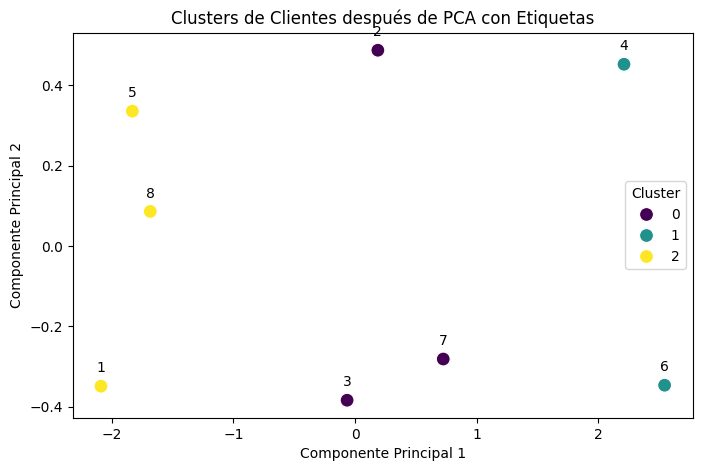


Cluster 0
   Cliente  Edad  Ingresos  Años de Experiencia Estado de Cuenta  \
1        2    40     60000                   10           Moroso   
2        3    35     70000                    7           Pagado   
6        7    38     72000                   12           Pagado   

   Estado_Cuenta_Cod  Cluster  
1                  1        0  
2                  0        0  
6                  0        0  

Cluster 1
   Cliente  Edad  Ingresos  Años de Experiencia Estado de Cuenta  \
3        4    50     80000                   15           Moroso   
5        6    45     85000                   20           Moroso   

   Estado_Cuenta_Cod  Cluster  
3                  1        1  
5                  1        1  

Cluster 2
   Cliente  Edad  Ingresos  Años de Experiencia Estado de Cuenta  \
0        1    25     50000                    2           Pagado   
4        5    30     45000                    3           Pagado   
7        8    29     48000                    4           Pag

In [13]:
# 3) Aplicar Clustering K-Means
# Agrupar los atos en 3 cluster, según su similitud
kmeans = KMeans(n_clusters=3, random_state=42)
df_pca["Cluster"] = kmeans.fit_predict(df_pca)

# Asignar los clusters al DataFrame original
df["Cluster"] = df_pca["Cluster"]

# Visualizar Clustering
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df_pca["PC1"], y=df_pca["PC2"], hue=df_pca["Cluster"], palette="viridis", s=100)

# Añadir etiquetas de cliente a cada punto
for i, txt in enumerate(df['Cliente']):
    plt.annotate(txt, (df_pca['PC1'][i], df_pca['PC2'][i]), textcoords="offset points", xytext=(0,10), ha='center')

plt.title("Clusters de Clientes después de PCA con Etiquetas")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.show()

for i in range(3):
    print(f"\nCluster {i}")
    print(df[df['Cluster'] == i])

En el gráfico podemos ver la distribución de los 8 clientes, en un espacio 2D. La cercanía entre puntos, indica similitd entre clientesLa distancia entre cada punto, indicaque tan diferentes son esos clientes. Esta visualización nos permite identificar los siguientes patrones entre los cliente:


1.  El cluster 0, contiene a los clientes edad promedio(45-50 años), con ingresos promedios, experiencia moderada y alternan entre morosos y clientes al día.
2.  El cluster 1, contiene a los clientes edad mayores(45-50 años), con ingresos mayores, gran experiencia y presentan deuda ensu estado de cuentas.
3.  El cluster 2, contiene a los clientes jovenes (25-30  años), con ingresos bajos,  poca experiencia y mantienen su estado de cuentas al día.


# **4. Interacción con una Herramienta de IA (LLM)**

◦ Hacer una consulta a ChatGPT, Gemini u otra herramienta LLM para obtener insights sobre los clusters.


◦ Ejemplo de consulta: "Tengo datos de clientes con variables de edad, ingresos y experiencia. ¿Qué técnicas avanzadas puedo usar para
mejorar la segmentación?"

◦ Comparar la respuesta con lo aprendido en la clase y reflexionar sobre su utilidad.

#*Consulta a Gemini, para obtener insights sobre los clusters.*

**Reflexión**

Comparando la respuesta con lo aprendido en clase, observo que ambas se complementan en pos de obtener los mejores resultados al momento de analizar un dataset. El proceso EDA, junto con análisis univariado y multivariado, ofrecen una base sólida para aplicar técnicas avanzadas como DBSCAN o análisis de estabilidad. En la clase  podemos comprender la distribución y patrones, luego mediante modelos interpretables (árbol de desición) se generan "insights accionables" para definir qué caracteriza a cada segmento. Por último sugiere el uso de técnicas que permiten medir la Robustez del Análisis, para asegurar que los hallazgos no sean fruto del azar y garantizar la consistencia de los clusteres identificados.